# Week 5 – UHPC Dataset Import and 28-Day Target Check

I have prepared this notebook for the task of Week 5 under **Data to Design: Structural Materials**.  
For this week, the main purpose is not to build a machine learning model yet. The purpose is to understand the UHPC Excel file, import it correctly, clean the column headers, and check how many rows can be used when the target is **28-day compressive strength**.

In this notebook I do the following steps:

1. Set up the folder paths.
2. Find the UHPC Excel file, even if it is still inside the ZIP file.
3. Read the Excel file with the correct multi-row header.
4. Clean the column names into readable names.
5. Find the 28-day compressive strength column.
6. Count how many rows contain this target value.
7. Make a small summary table and a simple plot.
8. Write a short interpretation for the Week 5 answer.


In [3]:
from pathlib import Path
import zipfile
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
import subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl"])

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

print("Libraries imported successfully.")

Libraries imported successfully.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


## 2. Path setup

This cell tries to make the notebook work in a normal project structure.  
If the notebook is inside a `notebooks` folder, the project folder is taken as one level above it.  
If the notebook is run from the main week folder, that folder is used directly.

The important folder for the raw dataset is:

```text
data/raw/
```


In [4]:
# Current working directory used by Jupyter
CWD = Path.cwd().resolve()

# If the notebook is opened from a notebooks folder, go one level up.
# Otherwise, use the current folder as the week/project folder.
if CWD.name.lower() == "notebooks":
    WEEK_DIR = CWD.parent
else:
    WEEK_DIR = CWD

DATA_DIR = WEEK_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = WEEK_DIR / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"
RESULTS_DIR = WEEK_DIR / "results"

# Create folders if they do not already exist.
for folder in [RAW_DIR, PROCESSED_DIR, FIGURES_DIR, TABLES_DIR, RESULTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Current working directory:", CWD)
print("Week/project directory:", WEEK_DIR)
print("Raw data directory:", RAW_DIR)
print("Processed data directory:", PROCESSED_DIR)
print("Figures directory:", FIGURES_DIR)
print("Tables directory:", TABLES_DIR)

Current working directory: /Users/apple/Brijesh/DE/SoSe2026/Special Project/Da2De/S1_Linear/notebooks
Week/project directory: /Users/apple/Brijesh/DE/SoSe2026/Special Project/Da2De/S1_Linear
Raw data directory: /Users/apple/Brijesh/DE/SoSe2026/Special Project/Da2De/S1_Linear/data/raw
Processed data directory: /Users/apple/Brijesh/DE/SoSe2026/Special Project/Da2De/S1_Linear/data/processed
Figures directory: /Users/apple/Brijesh/DE/SoSe2026/Special Project/Da2De/S1_Linear/reports/figures
Tables directory: /Users/apple/Brijesh/DE/SoSe2026/Special Project/Da2De/S1_Linear/reports/tables


## 3. Find the UHPC Excel file

The dataset may be available in one of two ways:

1. The Excel file is already extracted, for example:

```text
UHPC Dataset  (Version-2).xlsx
```

2. The original ZIP file is still in the raw data folder. In that case, the notebook searches inside the ZIP file and extracts the UHPC dataset Excel file.


In [5]:
def find_uhpc_excel(search_dirs):
    """Find the main UHPC dataset Excel file.

    The function first searches for an already extracted Excel file.
    If it cannot find one, it searches ZIP files and extracts the needed Excel file.
    """
    # 1) Search for extracted Excel files
    excel_candidates = []
    for base in search_dirs:
        if base.exists():
            excel_candidates.extend(base.rglob("*.xlsx"))

    # Prefer the main UHPC dataset file, not the summary file.
    main_excel_candidates = [
        path for path in excel_candidates
        if "uhpc dataset" in path.name.lower()
        and "summary" not in path.name.lower()
        and not path.name.startswith("~$")
    ]

    if main_excel_candidates:
        return sorted(main_excel_candidates, key=lambda p: len(str(p)))[0]

    # 2) If no Excel file was found, search inside ZIP files
    zip_candidates = []
    for base in search_dirs:
        if base.exists():
            zip_candidates.extend(base.rglob("*.zip"))

    zip_candidates = [
        path for path in zip_candidates
        if "uhpc" in path.name.lower() or "global dataset" in path.name.lower()
    ]

    for zip_path in zip_candidates:
        extract_dir = RAW_DIR / "extracted_from_zip"
        extract_dir.mkdir(parents=True, exist_ok=True)

        with zipfile.ZipFile(zip_path, "r") as zf:
            members = zf.namelist()
            main_members = [
                m for m in members
                if m.lower().endswith(".xlsx")
                and "uhpc dataset" in Path(m).name.lower()
                and "summary" not in Path(m).name.lower()
            ]

            if main_members:
                member = main_members[0]
                zf.extract(member, extract_dir)
                return extract_dir / member

    raise FileNotFoundError(
        "Could not find the UHPC dataset Excel file. "
        "Please place 'UHPC Dataset  (Version-2).xlsx' or the original UHPC ZIP file inside data/raw/."
    )

# Search in the week folder and also one level above, because sometimes Jupyter is started from the repository root.
search_dirs = [WEEK_DIR, WEEK_DIR.parent, RAW_DIR, CWD]

xlsx_path = find_uhpc_excel(search_dirs)
print("Excel file used:")
print(xlsx_path)

Excel file used:
/Users/apple/Brijesh/DE/SoSe2026/Special Project/Da2De/S1_Linear/data/raw/UHPC Dataset  (Version-2).xlsx


## 4. Check the workbook sheets

Before reading the data, I first check the sheet names. This is useful because the Excel workbook contains more than one sheet. The main data sheet is the sheet named **UHPC Dataset**.


In [6]:
excel_file = pd.ExcelFile(xlsx_path, engine="openpyxl")

sheets = pd.DataFrame({
    "sheet_index": list(range(len(excel_file.sheet_names))),
    "sheet_name": excel_file.sheet_names
})

display(sheets)

,sheet_index,sheet_name
0,0,Readme
1,1,UHPC Dataset
2,2,Reference and Data sources
3,3,Testing Standard
4,4,Cement Composition
5,5,Silica Fume Composition
6,6,Slag Composition
7,7,Flyash Composition
8,8,Limestone Composition
9,9,Metakaolin Composition


## 5. Import the main UHPC dataset

The UHPC dataset uses a header over multiple rows.  
That is why I read the sheet with:

```python
header=[0, 1, 2]
```

This keeps the three header rows together as a multi-level header. After reading the file, I will convert these multi-level column names into normal readable column names.


In [7]:
# Select the main data sheet.
# The strip() is used because some sheet names contain spaces at the end.
dataset_sheet = None
for sheet in excel_file.sheet_names:
    if sheet.strip().lower() == "uhpc dataset":
        dataset_sheet = sheet
        break

if dataset_sheet is None:
    # Fallback: in this workbook, the main dataset is normally sheet index 1.
    dataset_sheet = excel_file.sheet_names[1]

print("Dataset sheet used:", repr(dataset_sheet))

raw_df = pd.read_excel(
    xlsx_path,
    sheet_name=dataset_sheet,
    header=[0, 1, 2]
)

print("Raw dataframe shape:", raw_df.shape)
display(raw_df.head())

Dataset sheet used: 'UHPC Dataset '
Raw dataframe shape: (2188, 92)


Mix-ID     Mix Constitutents                                                                                                                                               \
  Unnamed: 0_level_1                Binder                                                           Supplementary Cementitious Materials (SCMs)                                          
  Unnamed: 0_level_2 Cement Amount  (kg/m³)                         Cement type\t Cement Grade (Mpa)                         Silica Fume (kg/m³) Flayash Amount   (kg/m³) Fly Ash Type    
0            S10-F10                  839.0  Type I/II low-alkali portland cement                NaN                                       104.0                    104.0       Class-F   
1          S10-F5-N5                  839.0  Type I/II low-alkali portland cement                NaN                                       104.0                     52.0       Class-F   
2      S10-F2.5-N7.5                  839.0  Type I/II low-alkali portland cement                NaN                                       104.0                     26.0       Class-F   
3            S10-N10                  839.0  Type I/II low-alkali portland cement                NaN                                       104.0                      0.0           NaN   
4          S10-F5-M5                  839.0  Type I/II low-alkali portland cement                NaN                                       104.0                     52.0       Class-F   

                                                                                                                                                                                      \
                                                                                                                                                                     Nano Particles    
  Limestone Powder  (kg/m3) Quartzpowder (kg/m3) Glass powder (kg/m3) Rice husk ash (kg/m3) Metakaolin (kg/m³) GGBFS  (kg/m³) Slag Amount   (kg/m³) Type of Slag  Nano-CaCO3 (kg/m3)   
0                       0.0                  0.0                  0.0                   0.0                0.0            0.0                   0.0           NaN                0.0   
1                       0.0                  0.0                  0.0                   0.0                0.0            0.0                   0.0           NaN                0.0   
2                       0.0                  0.0                  0.0                   0.0                0.0            0.0                   0.0           NaN                0.0   
3                       0.0                  0.0                  0.0                   0.0                0.0            0.0                   0.0           NaN                0.0   
4                       0.0                  0.0                  0.0                   0.0               52.0            0.0                   0.0           NaN                0.0   

                                                                                                                                                                                                       \
                                                           Sustainable Filler                            Sand                                          Fiber                                            
  Nano-Al2O3 (kg/m3) Nano-TiO2 (kg/m3) Nano Silica (kg/m3)      Filler (kg/m³) Type of Filler  Amount  (kg/m³) Sand Type Max Size (mm)         Type of Fiber  Amount / Quantity of Fiber  Length (mm)   
0                0.0               0.0                 0.0                 0.0             NaN           919.0       NaN           NaN  Straight Steel Fiber                        119.0        13.0   
1                0.0               0.0                 0.0                52.0        Pumicite           925.0       NaN           NaN  Straight Steel Fiber                        119.0        13.0   
2                0.0               0.0 

## 6. Clean the multi-row column headers

The raw Excel file has column headers split over three rows. Pandas imports this as a multi-index column structure.  
For easier checking and later modelling, I join the useful parts of each header with `|`.

Example idea:

```text
Mechanical Properties | Compressive Strength (Mpa) | 28-Day
```

This makes it much easier to find the target column.


In [8]:
def clean_header_part(value):
    """Clean one part of a multi-row Excel header."""
    value = str(value).strip()

    # Pandas creates names like 'Unnamed: 0_level_1' when Excel header cells are empty.
    if value.startswith("Unnamed") or value.lower() == "nan":
        return ""

    # Replace line breaks and repeated spaces.
    value = re.sub(r"\s+", " ", value)
    return value

clean_columns = []
seen = {}

for col in raw_df.columns:
    parts = [clean_header_part(part) for part in col]
    parts = [part for part in parts if part != ""]

    name = " | ".join(parts)
    if name == "":
        name = "Unnamed_Column"

    # Avoid duplicate column names if any appear after cleaning.
    if name in seen:
        seen[name] += 1
        name = f"{name}_{seen[name]}"
    else:
        seen[name] = 0

    clean_columns.append(name)

df = raw_df.copy()
df.columns = clean_columns

print("Number of columns:", df.shape[1])
print("First 15 cleaned column names:")
for i, col in enumerate(df.columns[:15]):
    print(f"{i:02d}: {col}")

Number of columns: 92
First 15 cleaned column names:
00: Mix-ID
01: Mix Constitutents | Binder | Cement Amount (kg/m³)
02: Mix Constitutents | Binder | Cement type
03: Mix Constitutents | Binder | Cement Grade (Mpa)
04: Mix Constitutents | Supplementary Cementitious Materials (SCMs) | Silica Fume (kg/m³)
05: Mix Constitutents | Supplementary Cementitious Materials (SCMs) | Flayash Amount (kg/m³)
06: Mix Constitutents | Supplementary Cementitious Materials (SCMs) | Fly Ash Type
07: Mix Constitutents | Supplementary Cementitious Materials (SCMs) | Limestone Powder (kg/m3)
08: Mix Constitutents | Supplementary Cementitious Materials (SCMs) | Quartzpowder (kg/m3)
09: Mix Constitutents | Supplementary Cementitious Materials (SCMs) | Glass powder (kg/m3)
10: Mix Constitutents | Supplementary Cementitious Materials (SCMs) | Rice husk ash (kg/m3)
11: Mix Constitutents | Supplementary Cementitious Materials (SCMs) | Metakaolin (kg/m³)
12: Mix Constitutents | Supplementary Cementitious Materials

## 7. Find the 28-day compressive strength target column

For this Week 5 task, the most important target column is the **28-day compressive strength**.  
I search for the column name containing:

- `Compressive Strength`
- `28-Day`

Then I convert this column to numeric values. Any non-numeric or empty value becomes `NaN`, which means it cannot be used as a valid target value.


In [9]:
target_matches = [
    col for col in df.columns
    if "compressive strength" in col.lower()
    and "28" in col.lower()
    and "day" in col.lower()
]

print("Target column matches:")
for col in target_matches:
    print("-", col)

if len(target_matches) == 0:
    raise ValueError("No 28-day compressive strength column was found.")

# In this dataset, the first match is the correct target column.
target_col = target_matches[0]
print("\nSelected target column:", target_col)

# Convert the target to numeric.
df[target_col] = pd.to_numeric(df[target_col], errors="coerce")

Target column matches:
- Mechanical Properties | Compressive Strength (Mpa) | 28-Day

Selected target column: Mechanical Properties | Compressive Strength (Mpa) | 28-Day


## 8. Count rows with the 28-day target

The PDF says that the file has **2,188 rows**, but the important question is how many of those rows actually contain the 28-day compressive strength.  
For supervised machine learning, a row is only useful for this target if the target value is available.


In [10]:
total_rows = len(df)
rows_with_target = int(df[target_col].notna().sum())
missing_target = int(df[target_col].isna().sum())
usable_percentage = rows_with_target / total_rows * 100

summary_table = pd.DataFrame({
    "Item": [
        "Total rows in UHPC dataset",
        "Rows with valid 28-day compressive strength",
        "Rows missing 28-day compressive strength",
        "Usable rows for 28-day target modelling (%)"
    ],
    "Value": [
        total_rows,
        rows_with_target,
        missing_target,
        round(usable_percentage, 2)
    ]
})

display(summary_table)

# Save the summary table for the report.
# summary_table_path = TABLES_DIR / "week05_28day_target_row_count.csv"
# summary_table.to_csv(summary_table_path, index=False)
# print("Saved summary table to:", summary_table_path)

,Item,Value
0,Total rows in UHPC dataset,2188.00
1,Rows with valid 28-day compressive strength,2073.00
2,Rows missing 28-day compressive strength,115.00
3,Usable rows for 28-day target modelling (%),94.74


### My interpretation of the row count

The dataset contains **2,188 rows** in total. After converting the 28-day compressive strength column into numeric values, I found that **2,073 rows** contain a valid 28-day strength value. This means **115 rows** are missing this target value.

So, for a model that predicts 28-day compressive strength, I should start with the **2,073 rows** where the target is available. I should not use rows with missing target values for supervised training, because the model needs a known output value for each training example.


## 9. Basic statistics of the 28-day compressive strength

After counting the available target values, I also check the basic statistics. This gives a first idea of the range and distribution of the target.


In [11]:
target_values = df[target_col].dropna()

stats_table = target_values.describe().to_frame(name="28-day compressive strength (MPa)")
stats_table.loc["median"] = target_values.median()
stats_table = stats_table.loc[["count", "mean", "std", "min", "25%", "50%", "median", "75%", "max"]]

# Round only for display, not for original data.
display(stats_table.round(3))

stats_table_path = TABLES_DIR / "week05_28day_target_statistics.csv"
stats_table.to_csv(stats_table_path)
print("Saved statistics table to:", stats_table_path)

,28-day compressive strength (MPa)
count,2073.000
mean,150.193
std,36.365
min,80.000
25%,124.850
50%,145.100
median,145.100
75%,170.000
max,298.000


Saved statistics table to: /Users/apple/Brijesh/DE/SoSe2026/Special Project/Da2De/S1_Linear/reports/tables/week05_28day_target_statistics.csv


### My interpretation of the target statistics

The 28-day compressive strength values are mostly in the UHPC strength range. The values start from around **80 MPa** and go up to almost **300 MPa**. The mean value is around **150 MPa**, and the median is slightly lower than the mean.

This tells that the target is not a small-strength normal concrete dataset. It is really focused on UHPC and very high-strength mixtures. The difference between the mean and median also suggests that some very high-strength mixes pull the average upward.


## 10. Plot the 28-day compressive strength distribution

A histogram helps me see how the target values are spread. I also add the mean and median as vertical reference lines.


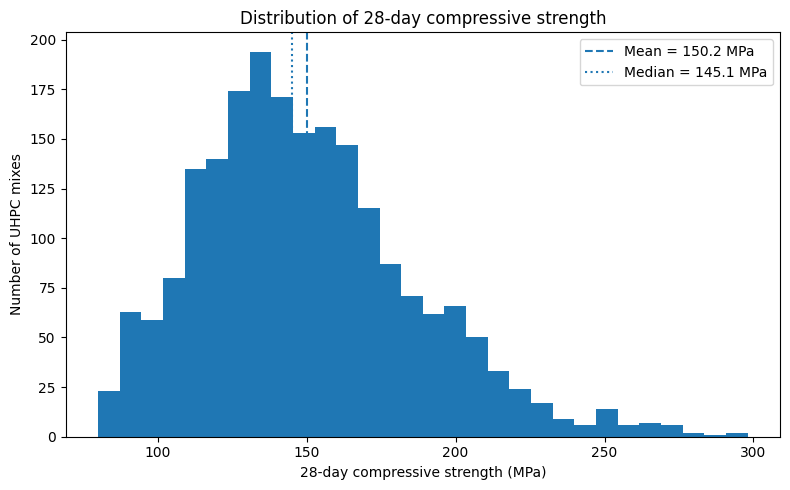

Saved figure to: /Users/apple/Brijesh/DE/SoSe2026/Special Project/Da2De/S1_Linear/reports/figures/week05_28day_strength_distribution.png


In [17]:
plt.figure(figsize=(8, 5))
plt.hist(target_values, bins=30)
plt.axvline(target_values.mean(), linestyle="--", label=f"Mean = {target_values.mean():.1f} MPa")
plt.axvline(target_values.median(), linestyle=":", label=f"Median = {target_values.median():.1f} MPa")
plt.xlabel("28-day compressive strength (MPa)")
plt.ylabel("Number of UHPC mixes")
plt.title("Distribution of 28-day compressive strength")
plt.legend()
plt.tight_layout()

figure_path = FIGURES_DIR / "week05_28day_strength_distribution.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:", figure_path)

## 11. Check missing values in the dataset

The Week 5 task also asks how blank cells should be interpreted. Before deciding anything, I first check which columns have many missing values.

In this kind of composition dataset, a blank cell should not automatically be treated as zero. A blank value can mean:

- the ingredient was not used,
- the ingredient amount was not reported,
- the information is not applicable for that mix,
- or the paper did not give that detail.

Because these meanings are different, I need to be careful before filling missing values.


In [18]:
missing_table = (
    df.isna()
    .sum()
    .to_frame("missing_count")
)
missing_table["missing_percentage"] = missing_table["missing_count"] / len(df) * 100
missing_table = missing_table.sort_values("missing_count", ascending=False)

# Show the 25 columns with the most missing values.
display(missing_table.head(25).round(2))

missing_table_path = TABLES_DIR / "week05_missing_values_by_column.csv"
missing_table.to_csv(missing_table_path)
print("Saved missing-value table to:", missing_table_path)

,missing_count,missing_percentage
Durability Properities | Surface Resistivity | Surface Resistivity (kΩ-mm),2175,99.41
Mechanical Properties | Compressive Strength (Mpa) | 21 days,2175,99.41
Durability Properities | Surface Resistivity | Testing Standards,2175,99.41
Durability Properities | Freezing and Thawing | Testing Standards,2166,98.99
Durability Properities | Freezing and Thawing | Cycles,2166,98.99
Durability Properities | Water absorption | Water absorption (%),2165,98.95
Durability Properities | Water absorption | Testing Standards,2165,98.95
Workability | Slump (mm),2159,98.67
Mechanical Properties | Tensile Strength Parameters | Tensile Elastic Modulus (GPa),2153,98.40
Durability Properities | Air Content/Air Void/ Porosity | Air Void %,2150,98.26


Saved missing-value table to: /Users/apple/Brijesh/DE/SoSe2026/Special Project/Da2De/S1_Linear/reports/tables/week05_missing_values_by_column.csv


### My interpretation of blank cells

For this dataset, I should not blindly replace every blank cell with zero. For example, if a material amount is exactly `0`, then this can mean that the material is absent. But if the cell is blank, it may mean that the value was not reported in the source paper.

For a first clean dataset, I would handle this as follows:

- keep explicit numeric zero values as zero,
- keep blank cells as missing values first,
- later decide column by column whether missing values should be filled with zero or imputed,
- use related columns to check the meaning. For example, if the fiber type and fiber amount are both missing, then it may mean no fiber was used, but this still needs careful checking.


## 12. Detect simple range-like text values

The PDF also mentions that some cells contain ranges. A range like `60 - 65` cannot be used directly as a normal numeric value.  
For a first practical solution, I can convert the range to the midpoint. For example:

```text
60 - 65  →  62.5
```

Before applying such a rule, I first check whether range-like values exist in text columns.


In [19]:
range_pattern = re.compile(r"^\s*[-+]?\d+(?:\.\d+)?\s*[-–]\s*[-+]?\d+(?:\.\d+)?\s*$")

range_counts = []
for col in df.columns:
    if df[col].dtype == "object":
        count = df[col].astype(str).str.match(range_pattern, na=False).sum()
        if count > 0:
            examples = df.loc[df[col].astype(str).str.match(range_pattern, na=False), col].dropna().astype(str).head(3).tolist()
            range_counts.append({
                "column": col,
                "range_like_count": int(count),
                "examples": examples
            })

range_table = pd.DataFrame(range_counts).sort_values("range_like_count", ascending=False) if range_counts else pd.DataFrame(columns=["column", "range_like_count", "examples"])
display(range_table)

range_table_path = TABLES_DIR / "week05_range_like_text_values.csv"
range_table.to_csv(range_table_path, index=False)
print("Saved range-like value table to:", range_table_path)

,column,range_like_count,examples


Saved range-like value table to: /Users/apple/Brijesh/DE/SoSe2026/Special Project/Da2De/S1_Linear/reports/tables/week05_range_like_text_values.csv


In [20]:
def range_to_midpoint(value):
    """Convert a simple numeric range string to its midpoint.

    Examples:
    '60 - 65' -> 62.5
    '85–96' -> 90.5

    If the value is not a range, it is returned unchanged.
    """
    if pd.isna(value):
        return np.nan

    if isinstance(value, str):
        match = re.match(r"^\s*([-+]?\d+(?:\.\d+)?)\s*[-–]\s*([-+]?\d+(?:\.\d+)?)\s*$", value)
        if match:
            low = float(match.group(1))
            high = float(match.group(2))
            return (low + high) / 2

    return value

# Small demonstration only
for example in ["60 - 65", "85–96", "42.5", np.nan]:
    print(f"{example!r} -> {range_to_midpoint(example)!r}")

'60 - 65' -> 62.5
'85–96' -> 90.5
'42.5' -> '42.5'
nan -> nan


### My interpretation of range values

Range cells should not stay as raw text if I want to use them in a machine learning model. A simple and understandable first method is to replace the range by its midpoint. A more detailed method would keep three values: lower value, upper value, and range width.

For Week 5, the midpoint method is enough to explain the idea clearly.


## 13. Decide the data type and encoding strategy

The next important part of Week 5 is to decide how different feature types should be handled. I separate the columns into broad groups instead of directly encoding everything.


In [21]:
feature_plan = pd.DataFrame([
    {
        "Feature group": "Mix ID and paper details",
        "Examples": "Mix-ID, reference details, country, year, paper reference",
        "Variable type": "Identifier / metadata",
        "Recommended handling": "Use for checking and traceability, but normally drop before modelling"
    },
    {
        "Feature group": "Material amounts",
        "Examples": "cement amount, silica fume, fly ash, sand, water, superplasticizer",
        "Variable type": "Continuous numeric",
        "Recommended handling": "Keep as numeric; check units; impute missing values carefully"
    },
    {
        "Feature group": "Cement grade",
        "Examples": "42.5, 52.5, 53 MPa",
        "Variable type": "Ordinal / numeric",
        "Recommended handling": "Extract the number and use it as a numeric feature"
    },
    {
        "Feature group": "Material type columns",
        "Examples": "cement type, fly ash type, sand type, fiber type",
        "Variable type": "Nominal categorical",
        "Recommended handling": "Clean spelling and group rare categories; then use one-hot encoding"
    },
    {
        "Feature group": "Curing regime",
        "Examples": "curing method, temperature, humidity, pressure",
        "Variable type": "Mixed: categorical + numeric",
        "Recommended handling": "One-hot encode curing method; keep temperature, humidity, and pressure as numeric"
    },
    {
        "Feature group": "Testing standard and specimen information",
        "Examples": "ASTM, EN, specimen size",
        "Variable type": "High-cardinality categorical / text",
        "Recommended handling": "Clean or group; for first model, keep only useful extracted information"
    },
    {
        "Feature group": "Other mechanical/durability outputs",
        "Examples": "7-day strength, 56-day strength, shrinkage, porosity",
        "Variable type": "Output-like variables",
        "Recommended handling": "Do not use as input for a pure mix-design to 28-day strength model"
    },
])

display(feature_plan)

feature_plan_path = TABLES_DIR / "week05_feature_type_and_encoding_plan.csv"
feature_plan.to_csv(feature_plan_path, index=False)
print("Saved feature plan to:", feature_plan_path)

,Feature group,Examples,Variable type,Recommended handling
0,Mix ID and paper details,"Mix-ID, reference details, country, year, paper reference",Identifier / metadata,"Use for checking and traceability, but normally drop before modelling"
1,Material amounts,"cement amount, silica fume, fly ash, sand, water, superplasticizer",Continuous numeric,Keep as numeric; check units; impute missing values carefully
2,Cement grade,"42.5, 52.5, 53 MPa",Ordinal / numeric,Extract the number and use it as a numeric feature
3,Material type columns,"cement type, fly ash type, sand type, fiber type",Nominal categorical,Clean spelling and group rare categories; then use one-hot encoding
4,Curing regime,"curing method, temperature, humidity, pressure",Mixed: categorical + numeric,"One-hot encode curing method; keep temperature, humidity, and pressure as numeric"
5,Testing standard and specimen information,"ASTM, EN, specimen size",High-cardinality categorical / text,"Clean or group; for first model, keep only useful extracted information"
6,Other mechanical/durability outputs,"7-day strength, 56-day strength, shrinkage, porosity",Output-like variables,Do not use as input for a pure mix-design to 28-day strength model


Saved feature plan to: /Users/apple/Brijesh/DE/SoSe2026/Special Project/Da2De/S1_Linear/reports/tables/week05_feature_type_and_encoding_plan.csv


### My interpretation of feature encoding

I should not use the same encoding method for every column. Numeric amount columns should stay numeric. Cement grade has a natural order, so it can be treated as an ordinal or numeric value. Text columns such as cement type and fiber type are nominal categories, so one-hot encoding is more suitable after cleaning.

Target encoding is possible for high-cardinality text columns, but I would not use it as the first method because it can easily cause data leakage if it is not done inside cross-validation. For a first Week 5 preprocessing plan, cleaning plus grouping rare categories plus one-hot encoding is easier to explain and safer.


## 14. Create a first modelling-ready subset for the target

This is not the final modelling dataset yet. It is only a first filtered dataset where the 28-day target is available.

For later modelling, I still need to decide which input columns to keep and how to encode them. But this filtered file is useful because it removes rows where the target is missing.


In [22]:
df_with_target = df[df[target_col].notna()].copy()

processed_path = PROCESSED_DIR / "uhpc_rows_with_28day_target.csv"
df_with_target.to_csv(processed_path, index=False)

print("Shape before filtering:", df.shape)
print("Shape after filtering for available 28-day target:", df_with_target.shape)
print("Saved filtered dataset to:", processed_path)

Shape before filtering: (2188, 92)
Shape after filtering for available 28-day target: (2073, 92)
Saved filtered dataset to: /Users/apple/Brijesh/DE/SoSe2026/Special Project/Da2De/S1_Linear/data/processed/uhpc_rows_with_28day_target.csv


## 15. Final Week 5 answer

Based on this notebook,

The UHPC Excel dataset contains **2,188 rows**. The data import needs care because the Excel file uses multi-row headers, and some information is stored as text or ranges. I imported the main UHPC dataset sheet using a three-row header and then cleaned the column names into readable names.

For the prediction task, I selected **28-day compressive strength** as the target variable. After converting this target column to numeric values, I found that **2,073 rows** contain a valid 28-day compressive strength value, while **115 rows** are missing this target. Therefore, for supervised modelling of 28-day compressive strength, the usable starting dataset contains **2,073 rows**.

Blank cells should not automatically be interpreted as zero. In a mix-design dataset, a zero value can mean that a material was not used, but a blank value can also mean that the information was not reported. Therefore, missing values should first be kept as missing and then handled column by column.

For feature encoding, continuous variables such as material amounts, water amount, sand amount, and superplasticizer amount should stay numeric. Ordinal or numeric information such as cement grade can be converted into a numeric value. Nominal text variables such as cement type, fiber type, sand type, and curing method should be cleaned and then encoded using one-hot encoding or grouped categories. High-cardinality text columns should not be directly encoded without cleaning, because this can create too many sparse and repeated categories.
